### Hi! I am trying to implement linear regression on a custom dataset below you may find the details about the dataset on which i am trying to implement.



## Columns

- **`area_sqft`** — continuous, strong positive driver of price
- **`bedrooms`** — 1–5, positive effect
- **`age_years`** — negative effect (older = cheaper), has 8 missing values
- **`distance_km_from_city`** — negative effect, exponentially distributed (most houses near center, a few far out), has 6 missing values
- **`location_tier`** — categorical (`Low`/`Medium`/`High`), needs one-hot or ordinal encoding
- **`price`** — target variable

### Step:1 Starting with importing the required Python Liabraries.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Step:2 Creating Dataframe and checking for first n values.

In [20]:
df  = pd.read_csv("../Datasets/house_prices_dataset.csv")
df.head(5)

,area_sqft,bedrooms,age_years,distance_km_from_city,location_tier,price
0,2098.00,3,NaN,4.05,Medium,288858
1,1717.00,3,1.5,4.74,Medium,244097
2,5033.78,3,41.3,7.34,Medium,543418
3,2713.80,5,6.4,5.80,Medium,393844
4,1659.50,3,16.8,20.15,Medium,221107


### Step:3 Exploring the dataset.

In [21]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   area_sqft              500 non-null    float64
 1   bedrooms               500 non-null    int64  
 2   age_years              492 non-null    float64
 3   distance_km_from_city  494 non-null    float64
 4   location_tier          500 non-null    object 
 5   price                  500 non-null    int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 23.6+ KB


area_sqft                0
bedrooms                 0
age_years                8
distance_km_from_city    6
location_tier            0
price                    0
dtype: int64

### Step:4 Cleaning the dataset.

In [22]:
df["age_years"] = df["age_years"].fillna(df["age_years"].median())

df["distance_km_from_city"] = df["distance_km_from_city"].fillna(
    df["distance_km_from_city"].median()
)


df.isnull().sum()

area_sqft                0
bedrooms                 0
age_years                0
distance_km_from_city    0
location_tier            0
price                    0
dtype: int64

### Step:5 Define Features and Target.

In [23]:
X = df.drop(columns=["price"])  # Features
y = df["price"]                 # Target variable

### Step:6 Train-Test-Split


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.2, random_state=42)

### Step:7 Train Model.

In [27]:
model = LinearRegression()
X_train_encoded = pd.get_dummies(
    X_train, columns=["location_tier"], dtype=float
)
X_test_encoded = pd.get_dummies(
    X_test, columns=["location_tier"], dtype=float
)

X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns, fill_value=0
)

model.fit(X_train_encoded, y_train)

LinearRegression()

### Step:8 Predictions

In [29]:
y_pred = model.predict(X_test_encoded)

### Step:9 Evaluation

In [30]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 16248.412951036122
MSE : 435331374.4569808
RMSE: 20864.596196834984
R² Score: 0.9381712988870289


### Step:10 Actual VS Predicted

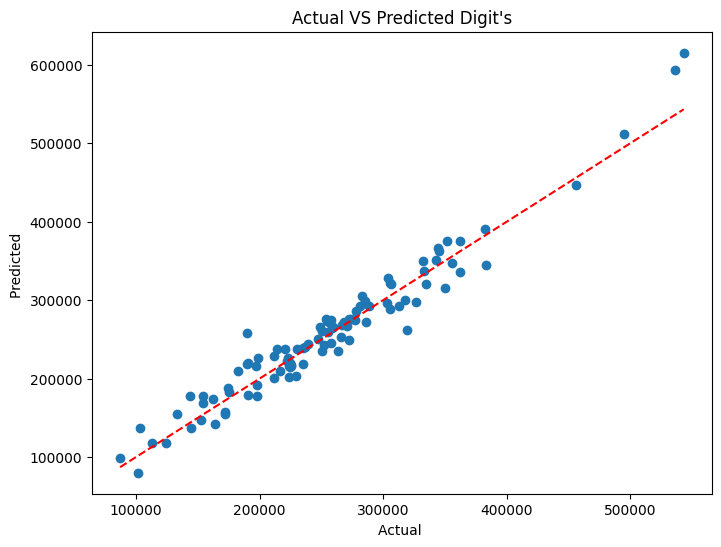

In [31]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred)
plt.xlabel("Actual ")
plt.ylabel("Predicted ")
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], 'r--') #perfect line
plt.title("Actual VS Predicted Digit's")
plt.show()